In [13]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
df=pd.read_csv(r"C:\Users\esair\Downloads\retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [2]:
x=df[['Age','Quantity','Total Amount','Price per Unit']]
y=df['Product Category']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_valid,y_train,y_valid=train_test_split(x_train,y_train,test_size=0.25,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_valid=scaler.transform(x_valid)
x_test=scaler.transform(x_test)
model=KNeighborsClassifier(n_neighbors=1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.375
              precision    recall  f1-score   support

      Beauty       0.42      0.30      0.35        73
    Clothing       0.35      0.38      0.37        60
 Electronics       0.37      0.45      0.41        67

    accuracy                           0.38       200
   macro avg       0.38      0.38      0.37       200
weighted avg       0.38      0.38      0.37       200

[[22 21 30]
 [16 23 21]
 [15 22 30]]


In [3]:
grid=GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={
        "n_neighbors":list(range(1,31))
    },
    cv=10,
    scoring='accuracy'
)
grid.fit(x_train, y_train)
print(grid.best_params_)
print(grid.best_score_)
print(grid.best_estimator_)
print(grid.cv_results_['mean_test_score'])

{'n_neighbors': 1}
0.3633333333333333
KNeighborsClassifier(n_neighbors=1)
[0.36333333 0.36166667 0.335      0.35       0.34833333 0.345
 0.32166667 0.31333333 0.34666667 0.33166667 0.34       0.33833333
 0.34166667 0.33       0.34666667 0.34833333 0.335      0.33166667
 0.33166667 0.32666667 0.335      0.33833333 0.345      0.35166667
 0.345      0.34666667 0.34166667 0.34166667 0.32666667 0.32666667]


In [1]:
#using a football dataset and making predictions
import pandas as pd
df=pd.read_csv(r"C:\Users\esair\OneDrive\Desktop\Lionel_Martinez_Anlysis\lionel-martinez-performance-analysis\data\fifa_world_cup_2026_player_performance.csv")
df


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54595,P00996,Amir Younis,28,Iraqi,Iraq,8,Defender,177,73,Right,...,0.0,41.9,27.7,31.3,40.5,1,0,97,0,0.0
54596,P01006,Safaa Al-Khafaji,20,Iraqi,Iraq,18,Midfielder,176,72,Right,...,0.0,64.2,53.1,64.8,64.3,2,0,206,0,0.0
54597,P01008,Ahmed Hussein,26,Iraqi,Iraq,20,Midfielder,173,77,Left,...,0.0,75.4,55.0,65.0,64.5,1,1,359,0,0.0
54598,P00991,Ibrahim Mhawi,30,Iraqi,Iraq,3,Goalkeeper,190,81,Right,...,0.0,96.3,39.6,99.0,99.0,0,0,342,0,0.0


In [5]:
#checking what are categorical columns and what are numerical columns
df_numerical=df.select_dtypes(include=['number']).columns.to_numpy()
df_numerical

array(['age', 'jersey_number', 'height_cm', 'weight_kg',
       'market_value_eur', 'goals_team', 'goals_opponent',
       'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target',
       'expected_goals_xg', 'expected_assists_xa', 'key_passes',
       'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves',
       'save_percentage', 'punches', 'clean_sheet', 'goals_conceded',
       'penalty_saves', 'distance_covered_km', 'sprint_distance_km',
       'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score',
       'player_rating', 'performance_score', 'offensive_contribution',
       'defensive_contribution', 'possession_impact',
       'pressure_r

In [6]:
df_categorical=df.select_dtypes(include=['object','string']).columns.to_numpy()
df_categorical

array(['player_id', 'player_name', 'nationality', 'team', 'position',
       'preferred_foot', 'club_name', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result'],
      dtype=object)

In [7]:
df=df
x=df[['height_cm','age','market_value_eur','goals','total_assists_tournament','tournament_rating']]
y=df['player_name']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_valid,y_train,y_valid=train_test_split(x_train,y_train,test_size=0.25,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_valid=scaler.transform(x_valid)
x_test=scaler.transform(x_test)
model=KNeighborsClassifier(n_neighbors=1)
model.fit(x_train,y_train)
y_valid_pred=model.predict(x_valid)
print(accuracy_score(y_valid,y_valid_pred))
print(classification_report(y_valid,y_valid_pred))
print(confusion_matrix(y_valid,y_valid_pred))


0.8251831501831501
                           precision    recall  f1-score   support

            Aaron Goodwin       1.00      0.71      0.83         7
           Aaron Metcalfe       0.91      1.00      0.95        10
            Aaron Souttar       1.00      1.00      1.00        10
             Aaron Wright       0.60      0.75      0.67        12
      Abdallah El-Shenawy       1.00      1.00      1.00         7
        Abdelaziz Abdulla       0.91      0.91      0.91        11
   Abdelaziz Al-Mohannadi       0.85      0.92      0.88        12
        Abdelaziz Ismaeel       0.91      0.91      0.91        11
             Abdiel Davis       0.75      0.86      0.80         7
          Abdiel Martinez       1.00      0.92      0.96        13
           Abdiel Sanchez       1.00      0.88      0.93         8
    Abdulrahman Al-Hamdan       0.88      0.94      0.91        16
    Abdulrahman Al-Otaibi       0.75      0.92      0.83        13
     Abdulrahman Al-Salem       0.85      

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x=df[['height_cm','age','goals','total_assists_tournament']]
y=df['market_value_eur']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_valid,y_train,y_valid=train_test_split(x_train,y_train,test_size=0.25,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
x_valid=scaler.transform(x_valid)
model=LinearRegression()
model.fit(x_train,y_train)
y_valid_pred=model.predict(x_valid)
print(y_valid_pred)
print(root_mean_squared_error(y_valid,y_valid_pred))
pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

[18062277.75203536 20704817.81710494 23341681.0548453  ...
 18552513.16005148 16515610.06257032 18062277.75203536]
27410890.072382722


,Feature,Coefficient
0,height_cm,-2.273873e+06
1,age,-1.338204e+06
2,goals,2.038829e+06
3,total_assists_tournament,1.577555e+06


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
data={
    'hours studied':[5,2,8],
    'attendance':[80,50,90],
    'result':['pass','fail','pass']
}
df=pd.DataFrame(data)
x=df[['hours studied','attendance']]
y=df['result']
encoder=LabelEncoder()
y=encoder.fit_transform(y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)
# x_train,x_valid,y_train,y_valid=train_test_split(x_train,y_train,test_size=0.25,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)
y_valid_pred=encoder.inverse_transform(model.predict([[1,100]]))
print(y_valid_pred)


['pass']


c:\Users\esair\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [10]:
import plotly.express as px
fig=px.bar(data_frame=df,x='hours studied',y='attendance',color='result')
fig.show()

In [24]:
df.column.to_excel()

AttributeError: 'DataFrame' object has no attribute 'column'

In [7]:
# Filters columns where every unique value is strictly 0, 1, or NaN
binary_cols = [col for col in df.columns if df[col].dropna().isin([0, 1, 0.0, 1.0]).all()]

# Create the new filtered DataFrame
df_binary = df[binary_cols]
df_binary.columns.to_frame()
df1=df_binary[df_binary['yellow_cards']==1].sum()
df1

yellow_cards     5346
red_cards           0
clean_sheet        39
penalty_saves      15
dtype: int64

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.preprocessing import LabelEncoder,StandardScaler
x=df[['player_rating','performance_score','minutes_played']]
y=df['tournament_rating']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))


[ 5.30054072e+00  5.63610448e-04  5.63610448e-04 ... -4.84159383e-04
  5.63610448e-04  6.29530975e+00]
MAE: 0.137113129728117
MSE: 0.05249558084640848
RMSE: 0.22911914116111834
R² Score: 0.9947663249530243


In [9]:
correlation=df.corr(numeric_only=True)
print(correlation['yellow_cards'].sort_values(ascending=False))

yellow_cards              1.000000
clearances                0.027987
defensive_actions         0.027367
defensive_contribution    0.024910
interceptions             0.020725
                            ...   
shots                    -0.019906
red_cards                -0.024733
offensive_contribution   -0.026285
jersey_number            -0.033475
creativity_score         -0.036520
Name: yellow_cards, Length: 61, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split
x=df[['clearances','defensive_contribution','interceptions']]
y=(df['yellow_cards']>0).astype(int)
target=93
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LogisticRegression(max_iter=1000)
player_features=x.iloc[[target]]
model.fit(x_train,y_train)
prob=model.predict_proba(player_features)[:,1]
threshold=0.40
y_pred=(prob>=threshold).astype(int)
print(y_pred.tolist())

[0]


In [11]:
ok=df.copy()
ok.nunique()

player_id                   1248
player_name                 1245
age                           23
nationality                   48
team                          48
                            ... 
total_goals_tournament        11
total_assists_tournament       9
total_minutes_tournament     586
player_of_match_awards         5
tournament_rating             63
Length: 75, dtype: int64

In [12]:
ok = df.groupby('player_name').agg({
    'goals': 'sum',
    'shots': 'sum',
    'shots_on_target': 'sum',
    'expected_goals_xg': 'sum',
    'performance_score': 'mean'
}).reset_index()
ok

,player_name,goals,shots,shots_on_target,expected_goals_xg,performance_score
0,Aaron Goodwin,1,12,0,0.06,34.787234
1,Aaron Metcalfe,1,32,2,1.56,38.989362
2,Aaron Souttar,0,0,0,0.00,20.893617
3,Aaron Wright,9,35,5,1.24,45.925532
4,Abdallah El-Shenawy,0,8,0,0.10,36.260000
...,...,...,...,...,...,...
1240,Youssef Laidouni,1,7,0,0.16,38.404255
1241,Youssef Skhiri,0,0,0,0.00,29.751064
1242,Yunus Robinson,2,3,0,0.01,35.457895
1243,Yusuf Kilicsoy,1,15,0,0.02,35.518000


In [13]:
ok['target']=(ok['goals']>10).astype(int)
ok

,player_name,goals,shots,shots_on_target,expected_goals_xg,performance_score,target
0,Aaron Goodwin,1,12,0,0.06,34.787234,0
1,Aaron Metcalfe,1,32,2,1.56,38.989362,0
2,Aaron Souttar,0,0,0,0.00,20.893617,0
3,Aaron Wright,9,35,5,1.24,45.925532,0
4,Abdallah El-Shenawy,0,8,0,0.10,36.260000,0
...,...,...,...,...,...,...,...
1240,Youssef Laidouni,1,7,0,0.16,38.404255,0
1241,Youssef Skhiri,0,0,0,0.00,29.751064,0
1242,Yunus Robinson,2,3,0,0.01,35.457895,0
1243,Yusuf Kilicsoy,1,15,0,0.02,35.518000,0


In [14]:
print(df.columns)

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
x=ok[['shots','shots_on_target']]
y=ok['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=DecisionTreeClassifier(max_depth=10,class_weight='balanced',criterion='entropy',min_samples_leaf=5,min_samples_split=5)
model=model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


0.8634538152610441
              precision    recall  f1-score   support

           0       1.00      0.86      0.93       246
           1       0.08      1.00      0.15         3

    accuracy                           0.86       249
   macro avg       0.54      0.93      0.54       249
weighted avg       0.99      0.86      0.92       249

[[212  34]
 [  0   3]]


In [16]:
print(x.shape)
print(y.shape)

(1245, 2)
(1245,)


In [17]:
ok['target'].value_counts()

target
0    1213
1      32
Name: count, dtype: int64

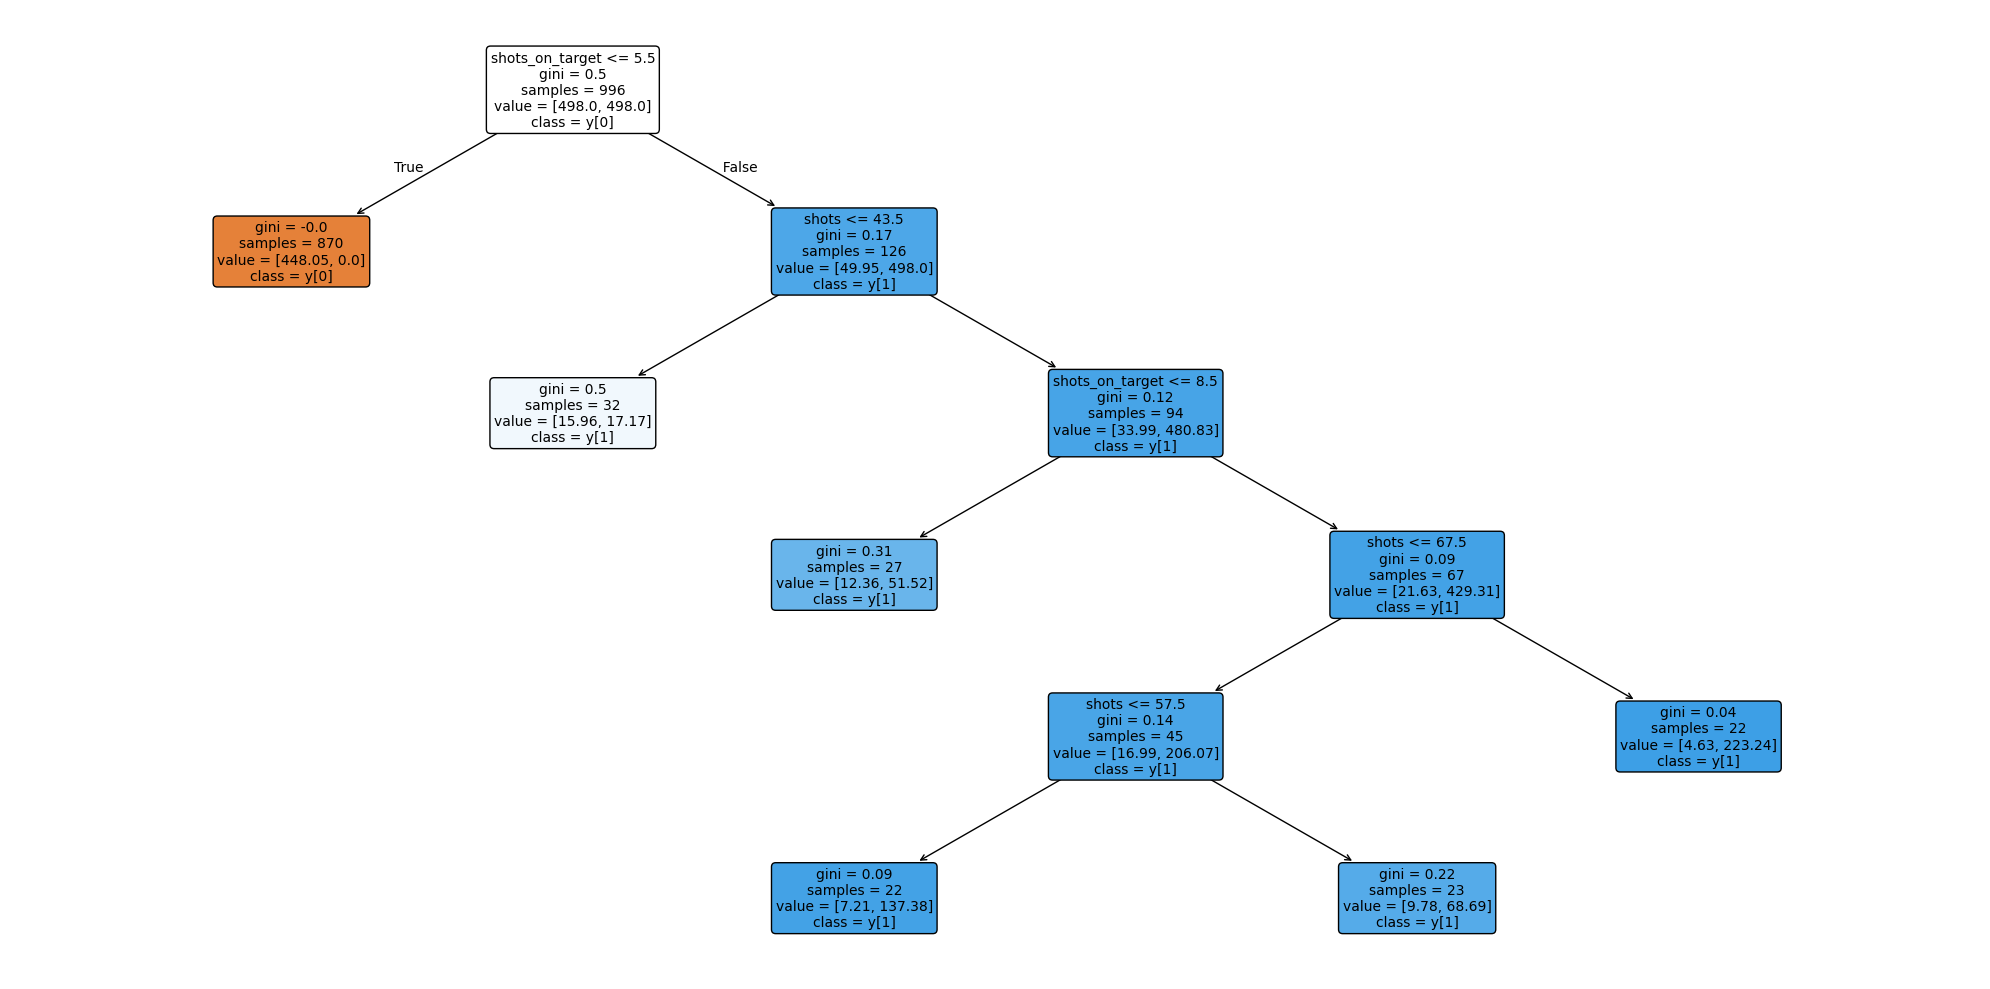

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(model,filled=True,feature_names=list(x.columns),class_names=True,rounded=True,fontsize=10,precision=2,)
plt.tight_layout()
plt.show()

In [19]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
})

importance
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance


,Feature,Importance
1,shots_on_target,0.971453
0,shots,0.028547


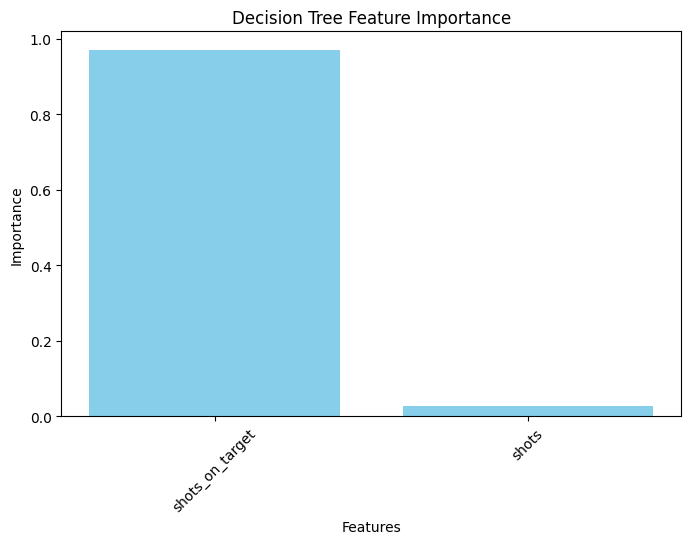

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(
    importance['Feature'],
    importance['Importance'],color='skyblue'
)
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.show()

In [21]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid.fit(x_train, y_train)

# train and search
best_model = grid.best_estimator_


# best parameters
print(grid.best_params_)

# best score
print(grid.best_score_)


{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5}
0.4194505494505495


In [ ]:
from sklearn.linear_model import LogisticRegression
data={'fruits':['apple','orange','promograne'],
      'sweetness':[100,120,90]}
df=pd.DataFrame(data)
x=df['fruits']
y=df['sweetness']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_stae=42)

    
